
# <b><u>❖ IML Micro Project ❖</u></b>
## <b><u>Child Screen Time - Addiction Level Predictor</u></b>
> This notebook predicts the child's `AddictionLevel` (1 to 5) using KNN.

---
### <u>Subject Detail</u>

**Subject Name:** Introduction to Machine Learning  
**Subject Code:** DI04000061  
**Subject Coordinator:** Mr. Shaktisinh S. Parmar  

---
### <u>Prepared By</u>
**Name:** SHIVAM MANISHKUMAR PANDYA  
**Enrollment No.:** 246090307077  
**Term:** 2025-2026 (Even Term)  
**Semester:** 4th (Four)  
**Division:** A  
**Department:** Diploma in Computer Engineering  
**College:** C. U. Shah Govt. Polytechnic - Surendranagar, GJ, IN.  

---

In [1]:
# 1) Import required libraries
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 2) Load dataset from current project folder
file_path = Path('child_screentime_dataset.csv')
df = pd.read_csv(file_path)

# Quick check of dataset size and top rows
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (555, 35)


,Age,Gender,DailyScreenTimeHours,WeekendScreenTimeHours,SocialMediaTimeHours,GamingTimeHours,VideoWatchingHours,EducationalContentHours,PhysicalActivityMinutes,SleepHours,...,HomeworkCompletionRate,ExtracurricularActivities,ReadingHabitsHours,CreativeActivityHours,EmotionalRegulationScore,ConflictWithParents,SchoolAttendanceRate,CyberbullyingExperience,OnlineFriendCount,AddictionLevel
0,8,0,2.5,3.5,0.5,1.0,1.0,0.5,90,9.5,...,95,2,1.5,1.0,8,1,98,0,5,1
1,9,1,3.0,4.0,1.0,1.5,1.0,0.5,75,9.0,...,90,2,1.0,0.5,7,2,96,0,8,2
2,10,0,4.5,6.0,2.0,2.0,1.5,0.5,60,8.5,...,85,1,0.5,0.5,6,3,94,1,12,3
3,11,1,5.5,7.0,2.5,2.5,2.0,0.5,45,8.0,...,75,1,0.5,0.5,5,4,90,1,18,4
4,12,0,7.0,9.0,3.5,3.0,2.5,0.5,30,7.5,...,65,0,0.0,0.0,4,5,85,2,25,5


In [2]:
# 3) Separate features (inputs) and target (output)
X = df.drop('AddictionLevel', axis=1)
y = df['AddictionLevel']

# 4) Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5) Scale feature values (important for KNN distance calculation)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 6) Train KNN model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_scaled, y_train)

# Keep this list for taking user inputs in same order as training
feature_columns = X.columns
print('Model trained. Total input features:', len(feature_columns))

Model trained. Total input features: 34


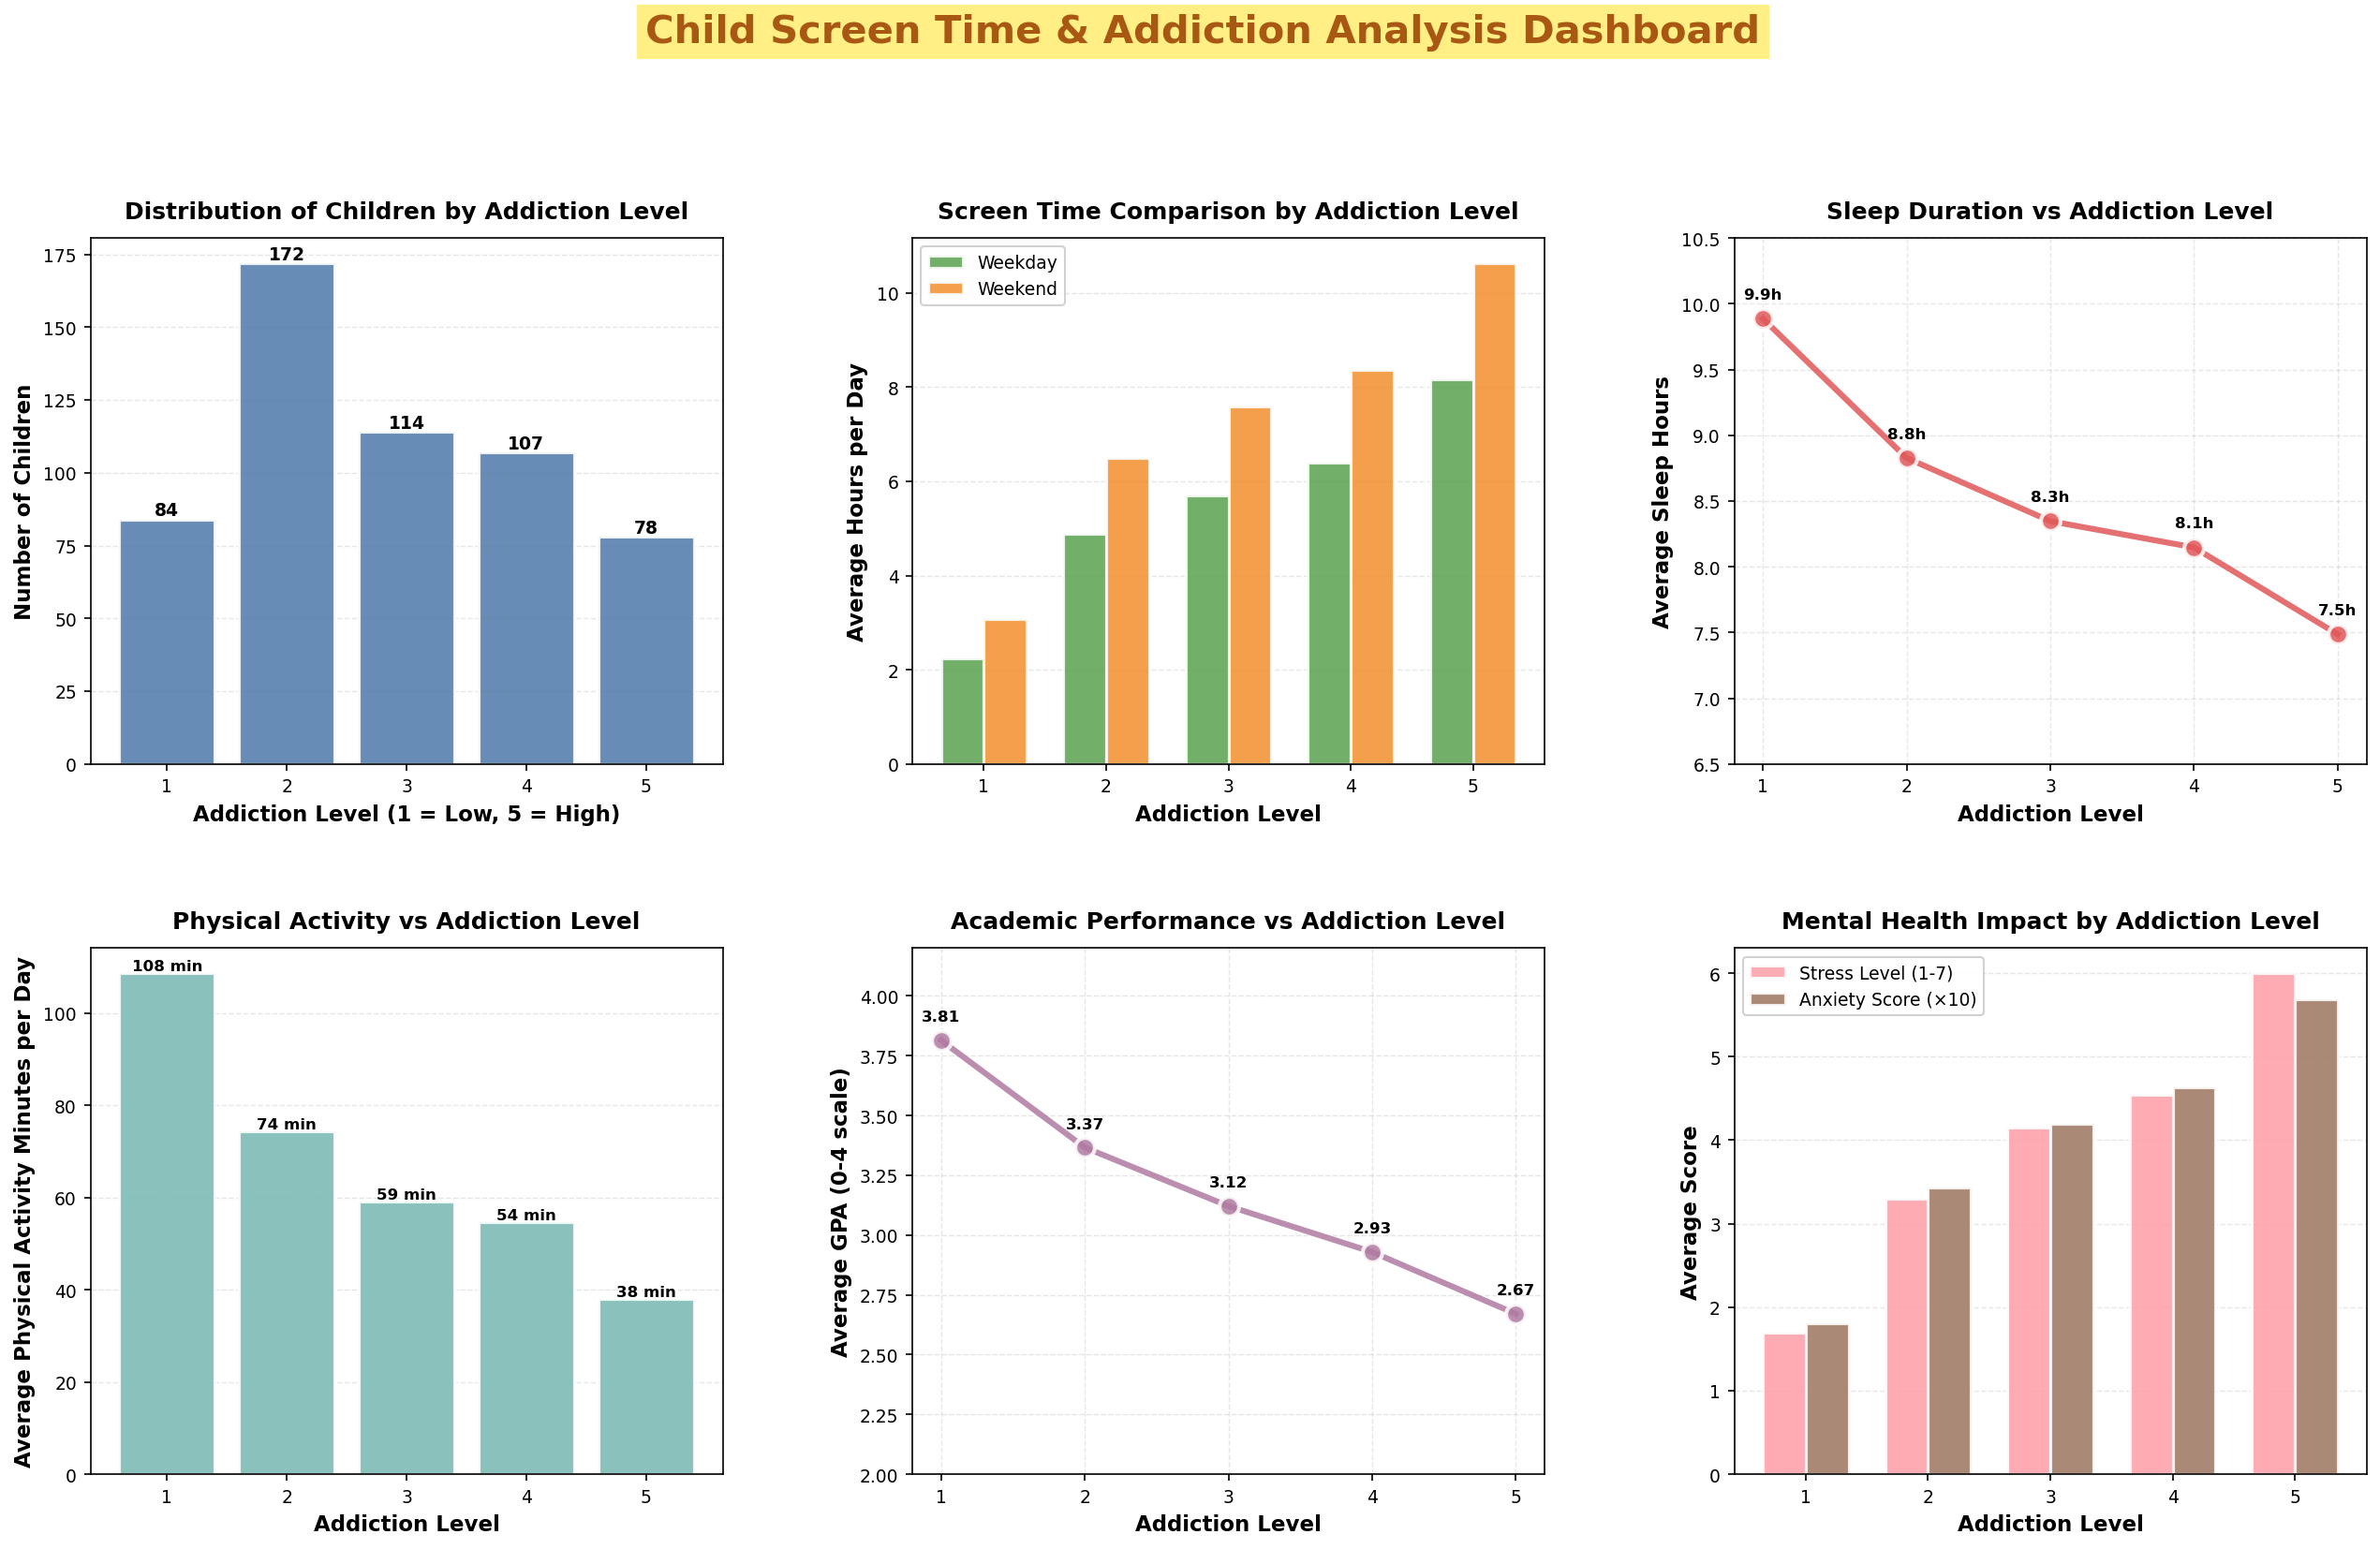

In [3]:
# Set high-quality parameters for SVG output
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text remains as text in SVG
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.dpi'] = 150

# Create a single figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Child Screen Time & Addiction Analysis Dashboard', 
             fontsize=20, fontweight='bold', y=1.1, color = "#A85813", backgroundcolor = "#FFEF84")

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.35, wspace=0.3, top=0.94, bottom=0.06, left=0.06, right=0.96)

# ============================================================================
# Visualization 1: Number of children in each addiction level
# ============================================================================
ax1 = axes[0, 0]
level_counts = df['AddictionLevel'].value_counts().sort_index()
bars1 = ax1.bar(level_counts.index, level_counts.values, color='#4C78A8', 
                edgecolor='white', linewidth=1.5, alpha=0.85)
ax1.set_title('Distribution of Children by Addiction Level', 
              fontweight='bold', pad=10)
ax1.set_xlabel('Addiction Level (1 = Low, 5 = High)', fontweight='bold')
ax1.set_ylabel('Number of Children', fontweight='bold')
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax1.set_axisbelow(True)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

# ============================================================================
# Visualization 2: Average daily and weekend screen time by addiction level
# ============================================================================
ax2 = axes[0, 1]
screen_avg = df.groupby('AddictionLevel')[['DailyScreenTimeHours', 'WeekendScreenTimeHours']].mean()
x = np.arange(len(screen_avg.index))
width = 0.35
bars2a = ax2.bar(x - width/2, screen_avg['DailyScreenTimeHours'], width, 
                 label='Weekday', color='#59A14F', edgecolor='white', 
                 linewidth=1.5, alpha=0.85)
bars2b = ax2.bar(x + width/2, screen_avg['WeekendScreenTimeHours'], width, 
                 label='Weekend', color='#F28E2B', edgecolor='white', 
                 linewidth=1.5, alpha=0.85)
ax2.set_title('Screen Time Comparison by Addiction Level', 
              fontweight='bold', pad=10)
ax2.set_xlabel('Addiction Level', fontweight='bold')
ax2.set_ylabel('Average Hours per Day', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([1, 2, 3, 4, 5])
ax2.legend(framealpha=0.9, loc='upper left')
ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax2.set_axisbelow(True)

# ============================================================================
# Visualization 3: Average sleep hours by addiction level
# ============================================================================
ax3 = axes[0, 2]
sleep_avg = df.groupby('AddictionLevel')['SleepHours'].mean()
line3 = ax3.plot(sleep_avg.index, sleep_avg.values, marker='o', 
                 color='#E15759', linewidth=3, markersize=10, 
                 markeredgecolor='white', markeredgewidth=2, alpha=0.85)
ax3.set_title('Sleep Duration vs Addiction Level', 
              fontweight='bold', pad=10)
ax3.set_xlabel('Addiction Level', fontweight='bold')
ax3.set_ylabel('Average Sleep Hours', fontweight='bold')
ax3.set_xticks([1, 2, 3, 4, 5])
ax3.grid(alpha=0.3, linestyle='--', linewidth=0.7)
ax3.set_axisbelow(True)
ax3.set_ylim([6.5, 10.5])

# Add value labels
for i, (level, sleep_hours) in enumerate(zip(sleep_avg.index, sleep_avg.values)):
    ax3.text(level, sleep_hours + 0.15, f'{sleep_hours:.1f}h', ha='center', 
            fontweight='bold', fontsize=8)

# ============================================================================
# Visualization 4: Average physical activity by addiction level
# ============================================================================
ax4 = axes[1, 0]
activity_avg = df.groupby('AddictionLevel')['PhysicalActivityMinutes'].mean()
bars4 = ax4.bar(activity_avg.index, activity_avg.values, color='#76B7B2', 
                edgecolor='white', linewidth=1.5, alpha=0.85)
ax4.set_title('Physical Activity vs Addiction Level', 
              fontweight='bold', pad=10)
ax4.set_xlabel('Addiction Level', fontweight='bold')
ax4.set_ylabel('Average Physical Activity Minutes per Day', fontweight='bold')
ax4.set_xticks([1, 2, 3, 4, 5])
ax4.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax4.set_axisbelow(True)

# Add value labels on bars
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)} min',
            ha='center', va='bottom', fontweight='bold', fontsize=8)

# ============================================================================
# Visualization 5: Average academic performance by addiction level
# ============================================================================
ax5 = axes[1, 1]
gpa_avg = df.groupby('AddictionLevel')['AcademicPerformanceGPA'].mean()
line5 = ax5.plot(gpa_avg.index, gpa_avg.values, marker='o', linewidth=3, 
                 color='#B07AA1', markersize=10, markeredgecolor='white', 
                 markeredgewidth=2, alpha=0.85)
ax5.set_title('Academic Performance vs Addiction Level', 
              fontweight='bold', pad=10)
ax5.set_xlabel('Addiction Level', fontweight='bold')
ax5.set_ylabel('Average GPA (0-4 scale)', fontweight='bold')
ax5.set_xticks([1, 2, 3, 4, 5])
ax5.grid(alpha=0.3, linestyle='--', linewidth=0.7)
ax5.set_axisbelow(True)
ax5.set_ylim([2.0, 4.2])

# Add value labels
for i, (level, gpa_value) in enumerate(zip(gpa_avg.index, gpa_avg.values)):
    ax5.text(level, gpa_value + 0.08, f'{gpa_value:.2f}', ha='center', 
            fontweight='bold', fontsize=8)

# ============================================================================
# Visualization 6: Mental Health Impact by Addiction Level
# ============================================================================
ax6 = axes[1, 2]
mental_health = df.groupby('AddictionLevel')[['StressLevel', 'AnxietyScore']].mean()
x = np.arange(len(mental_health.index))
width = 0.35

# Normalize anxiety score to 1-7 scale for better comparison with stress
anxiety_normalized = mental_health['AnxietyScore'] / 10

bars6a = ax6.bar(x - width/2, mental_health['StressLevel'], width, 
                 label='Stress Level (1-7)', color='#FF9DA7', 
                 edgecolor='white', linewidth=1.5, alpha=0.85)
bars6b = ax6.bar(x + width/2, anxiety_normalized, width, 
                 label='Anxiety Score (×10)', color='#9C755F', 
                 edgecolor='white', linewidth=1.5, alpha=0.85)
ax6.set_title('Mental Health Impact by Addiction Level', 
              fontweight='bold', pad=10)
ax6.set_xlabel('Addiction Level', fontweight='bold')
ax6.set_ylabel('Average Score', fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels([1, 2, 3, 4, 5])
ax6.legend(framealpha=0.9, loc='upper left')
ax6.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax6.set_axisbelow(True)

plt.savefig('child_screentime_analysis.png', format='png', dpi=600, bbox_inches='tight')
plt.show()


## 5 Test Cases (Model Check)

Below we use 5 sample rows from the dataset as test cases.
- `ActualLevel` is the value from dataset
- `PredictedLevel` is model output
- `Match` shows if prediction is correct

In [4]:
# Pick 5 sample cases from dataset
case_indices = [0, 1, 2, 3, 4]
test_X = X.iloc[case_indices].copy()
actual_y = y.iloc[case_indices].copy()

# Predict using trained model
pred_y = model.predict(scaler.transform(test_X))

# Build a simple result table
test_result = pd.DataFrame({
    'CaseNo': [1, 2, 3, 4, 5],
    'ActualLevel': actual_y.values,
    'PredictedLevel': pred_y,
})
test_result['Match'] = test_result['ActualLevel'] == test_result['PredictedLevel']

print('5 test cases with prediction result:')
test_result

5 test cases with prediction result:


,CaseNo,ActualLevel,PredictedLevel,Match
0,1,1,1,True
1,2,2,2,True
2,3,3,3,True
3,4,4,4,True
4,5,5,5,True


In [5]:
# 7) Function to take all feature values from user with clear labels
import re

def get_feature_label(col_name):
    # Hand-tuned labels for commonly used dataset columns
    custom_labels = {
        'DailyScreenTimeHours': 'Daily Screen Time Hours (Weekdays)',
        'WeekendScreenTimeHours': 'Weekend Screen Time Hours',
        'SleepHours': 'Sleep Hours per Night',
        'PhysicalActivityMinutes': 'Physical Activity (Minutes per Day)',
        'AcademicPerformanceGPA': 'Academic Performance (GPA)',
        'EducationalContentWatchHrs': 'Educational Content Watching Hours',
        'StressLevel': 'Stress Level',
        'AnxietyScore': 'Anxiety Score',
    }

    if col_name in custom_labels:
        return custom_labels[col_name]

    # Fallback: convert camel-case style names into readable text
    label = re.sub(r'([a-z0-9])([A-Z])', r'\1 \2', col_name)
    label = label.replace('Hrs', 'Hours')
    return label


def take_user_inputs(dataframe, columns):
    user_data = {}
    input_meta = {}

    for col in columns:
        # Show readable label and simple hint from existing data range
        label = get_feature_label(col)
        min_val = dataframe[col].min()
        max_val = dataframe[col].max()
        prompt = f'Enter {label} (suggested range: {min_val} to {max_val}): '

        while True:
            try:
                value = float(input(prompt))

                # Keep integer columns as integers
                if dataframe[col].dtype.kind in 'iu':
                    value = int(value)

                user_data[col] = value
                input_meta[col] = {
                    'label': label,
                    'min': min_val,
                    'max': max_val,
                }
                break
            except ValueError:
                print('Invalid value. Please enter a numeric value.')

    return user_data, input_meta

print('Input function is ready.')

Input function is ready.


In [6]:
# 8) Take user input for all features, then predict addiction level
user_input, input_meta = take_user_inputs(df, feature_columns)

print('\nUser Entered Data Summary:')
for col in feature_columns:
    info = input_meta[col]
    value = user_input[col]
    print(f"- {info['label']}: {value}")

# Convert input dict to DataFrame with correct column order
user_df = pd.DataFrame([user_input], columns=feature_columns)

# Apply same scaling used during training
user_df_scaled = scaler.transform(user_df)

# Predict addiction level (1 to 5)
predicted_level = int(model.predict(user_df_scaled)[0])
print('\nPredicted Addiction Level:', predicted_level)

if predicted_level == 1:
    print('Level 1: Very low risk; healthy and controlled screen-time habits.')
elif predicted_level == 2:
    print('Level 2: Mild risk; mostly balanced usage with occasional overuse.')
elif predicted_level == 3:
    print('Level 3: Moderate risk; noticeable dependency that needs monitoring.')
elif predicted_level == 4:
    print('Level 4: High risk; frequent overuse is affecting daily routine.')
elif predicted_level == 5:
    print('Level 5: Very high risk; severe dependency likely impacting health and academics.')
else:
    print('Prediction is outside expected range (1-5).')




User Entered Data Summary:
- Age: 17
- Gender: 1
- Daily Screen Time Hours (Weekdays): 2.5
- Weekend Screen Time Hours: 3.0
- Social Media Time Hours: 2.2
- Gaming Time Hours: 0.0
- Video Watching Hours: 0.2
- Educational Content Hours: 0.1
- Physical Activity (Minutes per Day): 15
- Sleep Hours per Night: 8.5
- Academic Performance (GPA): 3.7
- Attention Span Minutes: 37
- Social Interaction Score: 2
- Parental Supervision Level: 3
- Device Accessibility: 2
- Peer Influence: 1
- Stress Level: 3
- Anxiety Score: 2
- Depression Indicator: 0
- Eye Strain Frequency: 3
- Headache Frequency: 3
- Posture Problems: 2
- BMI: 16.0
- Outdoor Time Minutes: 11
- Family Meal Frequency: 2
- Homework Completion Rate: 88
- Extracurricular Activities: 1
- Reading Habits Hours: 1.0
- Creative Activity Hours: 1.0
- Emotional Regulation Score: 2
- Conflict With Parents: 1
- School Attendance Rate: 88
- Cyberbullying Experience: 0
- Online Friend Count: 0

Predicted Addiction Level: 3
Level 3: Moderate ri